In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
from astropy.io import fits
from utils import *
from tqdm.autonotebook import tqdm

In [ ]:
from collections import Counter
image_dir_search = 'proc/*.fits'
temperatures = []


for image in glob.glob(image_dir_search):
    temp = re.findall('_\d+k',image)[0][1:-1]
    if 'dtph' not in image:
        continue
    # if temp not in temperatures:
   
    temperatures.append(temp)
temperatures_strs = np.array(temperatures)

print(Counter(temperatures_strs))
# temperatures = np.unique(np.sort(temperatures))
temps = np.sort(np.array([int(t) for t in temperatures_strs]))

Counter({np.str_('200'): 58, np.str_('197'): 50, np.str_('183'): 50, np.str_('180'): 50, np.str_('193'): 50, np.str_('190'): 50, np.str_('207'): 50, np.str_('203'): 50, np.str_('187'): 50, np.str_('155'): 36, np.str_('170'): 36, np.str_('160'): 36, np.str_('145'): 36, np.str_('195'): 36, np.str_('125'): 36, np.str_('210'): 36, np.str_('140'): 36, np.str_('175'): 36, np.str_('130'): 36, np.str_('185'): 36, np.str_('150'): 36, np.str_('165'): 36, np.str_('135'): 36})


In [ ]:
from dipole import *
import pickle
goodQuads = [0,1,2,3]
image_dir = 'proc/'
test_temps = temperatures


try:
    with open('dipole_coord_list.pkl','rb') as infile:
        full_dipole_coord_list = pickle.load(infile)
except FileNotFoundError:
    full_dipole_coord_list = getDipoleList2(image_dir,test_temps,goodQuads)
    with open('dipole_coord_list.pkl','wb') as outfile:
        pickle.dump(full_dipole_coord_list,outfile)

        
try:
    with open('dipole_spectra.pkl','rb') as infile:
        dipole_spectra = pickle.load(infile)
except FileNotFoundError:
    dipole_spectra = getDipoleSpectra2(image_dir,goodQuads,full_dipole_coord_list)
    with open('dipole_spectra.pkl','wb') as outfile:
        pickle.dump(dipole_spectra,outfile)

useIntensityErr = True
wellBehavedThreshold = 4
threshold_str = f'_{wellBehavedThreshold}'
intensity_str = '_err' if useIntensityErr else ''
try:
    with open(f'fit_dipole_spectra{intensity_str}{threshold_str}.pkl','rb') as infile:
        fit_dipole_spectra = pickle.load(infile)

except FileNotFoundError:
    fit_dipole_spectra = fitTrapIntensity(dipole_spectra,useIntensityErr=useIntensityErr,wellBehavedThreshold=wellBehavedThreshold)
    with open(f'fit_dipole_spectra{intensity_str}{threshold_str}.pkl','wb') as outfile:
        pickle.dump(fit_dipole_spectra,outfile)

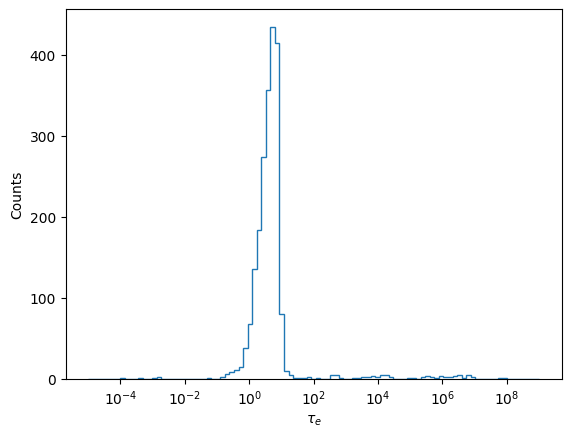

In [ ]:
tau_at_135s = []
for q in [0,1,2,3]:
    
    dpkeys = list(fit_dipole_spectra[q])
    for i in range(len(dpkeys)):
        
        # dpkeys = list(fit1_dipole_spectra[q])
        # dp = random.choice(dpkeys)
        dp = dpkeys[i]
        if type(dp) != tuple:
            continue
        testdp = fit_dipole_spectra[q][dp]
        if testdp['WellBehavedTrap'] and not testdp['EnergyFitFailed']:
            testdpfit = testdp['EnergyFitInfo']

            # p_value = testdpfit['p_value'] 
            # chi_squared = testdpfit['chi2']
            # r2 = testdpfit['r_squared']

            # pvals.append(p_value)
            # chi2s.append(chi_squared)
            # r2s.append(r2)
            # red_chi2s.append( testdpfit['reduced_chi2'])


            # fit_is_good = chi_squared < 100

            # fit_is_good = p_value < 0.05
            fit_is_good = testdp["GoodEnergyFit"]
            # fit_is_good = fit_is_good and 
            # maxtau = np.max(testdpfit['taus'])
            # maxtaus.append(maxtau)
            # fit_is_good = fit_is_good
            # fit_is_good = True


            if fit_is_good:
                cs = testdpfit['BestFitCrossSection']
                cserr = testdpfit['BestFitCrossSectionErr']
                e = testdpfit['BestFitEnergy']
                e_err = testdpfit['BestFitEnergyErr']

                 # temperatures = np.linspace(120,180,100)
                logtau_at_135 = log_energy_cross_section(135,e,np.log(cs))

                tau_at_135 = np.exp(logtau_at_135)
                tau_at_135s.append(tau_at_135)
              

                
                  
bins = np.geomspace(1e-5,1e9,100)
tau_at_135s = np.array(tau_at_135s)  
hist,bin_edges = np.histogram(tau_at_135s,bins)          
bin_centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
# stuff =  plt.hist(tau_at_135s,bins=bins)
plt.stairs(hist,bins)
plt.xlabel("$\\tau_e$")
plt.xscale('log')
plt.ylabel("Counts")
plt.show()
plt.close()

In [ ]:

len(hist),len(bin_edges),len(bin_centers)
tau_weights = hist
tau_values = bin_centers

In [ ]:
# def get_data():
#     import os
#     import re
#     datadir = '/data/analyses/minos_botti_1e_run42_trapsTest/'
#     mask_dir = '/data/analyses/minos_botti_1e_run42_trapsTest/new_cluster/'
#     datasets = []
#     for f in os.listdir(datadir):
#         if 'proc_corr_proc' not in f:
#             continue
#         if '_2_' not in f: continue
#         if '.fits' not in f:
#             continue

#         exposure = int(re.findall('EXPOSURE\d+',f)[0][8:])

#         maskfile = f.replace('proc_corr','mask_corr')
        
#         file = datadir + f
#         maskfile = mask_dir + maskfile
#         real_img = {}
#         mask_img = {}
#         halo_img = {}
#         for q in range(4):
#             qdata = get_qdata(file,q)
#             qdata = approximate_electronize(qdata,400)
#             real_img[q] = qdata

#             mask_data = get_qdata(maskfile,q)
#             mask_data = mask_data & (1+4+8+16+32+64+512+1024)
#             halo_only = mask_data & (8)
#             #1 -- neighbor
#             # 4 -- bleedzone
#             # 8 -- halo
#             # 16 -- crosstalk
#             # 32 -- noise (readout noise, listed as noisy image in globalConstants.cc, but name is out of date)
#             # 64 -- edge
#             # 512 -- bad pix (hot pixel)
#             # 1024 -- hot column
#             # 4096 -- extended bleed
#             # 8192 -- small cluster
#             # 32768 -- excluded cluster shape

#             mask_data = mask_data==0

#             halo_only = halo_only == 0

#             mask_img[q] = mask_data
#             halo_img[q] = halo_only
        
#         dataset = {
#             'exposure': exposure,
#             'image': real_img,
#             'mask': mask_img,
#             'halo': halo_img
#         }
#         datasets.append(dataset)

#     return datasets
    




# # Example Usage:
# # image = np.random.randint(50, 200, size=(20, 3200))
# # result = unbin_counts_conservative(image)


In [ ]:


UL_expdep = 8.19e-5 #e / pix / day

UR_expdep = 4.36e-5 #e / pix / day

LL_expdep = 6.88e-5 #e / pix / day

LR_expdep = 8.23e-5 #e / pix / day

UL_expindep = 12.23e-5 #e / superpix / image

UR_expindep = 9.94e-5 #e / superpix / image

LL_expindep = 7.53e-5 #e / superpix / image

LR_expindep = 6.52e-5 #e / superpix / day


#maybe just use lowest for now?
exp_dep_rate = UR_expdep / (24 * 3600) #e / pix / s

exp = 72000 # s



exp_indep_rate = UR_expindep/ 32 #e / pix / image
npix = (6144)* (1024)
npix_per_quad = npix / 4
print(npix_per_quad)

print(6144/2,1024/2)
exp_indep_events = exp_indep_rate * npix_per_quad
exp_indep_events = np.round(exp_indep_events)

exp_dep_events = exp_dep_rate * exp * npix

exp_dep_events = np.round(exp_dep_events)

print(exp_dep_events)
print(exp_indep_events)

n_singlee_events = int(exp_dep_events + exp_indep_events)

n_singlee_events = np.random.poisson(n_singlee_events)

print(f'Injecting {n_singlee_events} 1e events')
#now generate fake image
file = 'minos_image/proc_corr_proc_skp_72000secs_exp_run10_NSAMP_300_36.fits'

q0 = get_qdata(file,0)
print(q0.shape)

q0 =approximate_electronize(q0,400)
q0_blank= transplant_clusters(q0.T, target_shape=(512, 3072),count_threshold=20, max_aspect_ratio=3.0,radius=50)


q0_fake = inject_single_e(q0_blank, n_events=n_singlee_events, intensity=1)

trap_density = 5171 / (npix)


1572864.0
3072.0 512.0
229.0
5.0
Injecting 228 1e events
(3100, 470)
Exposure: 72000, Inserting approx 1024 clusters out of 1024


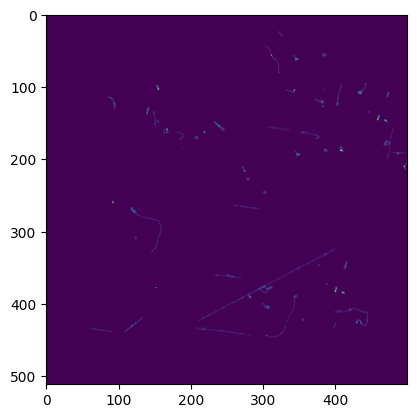

In [ ]:
plt.imshow(q0_fake[:,:500])

In [ ]:

from astropy.time import Time
#use a snolab image and assume this time is valid for pixel times

def pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG):		# Time to read 1 pixel
  return 5*int(delayH)+int(delayRG)+(int(delayIped)+int(delaySW)+int(delayIsig)+int(delayOG)+int(delayRG))*int(nsamp)

def pixel_time_vertical(nsamp,ncol, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG,delayDG):		# Time to read 1 pixel
  pixel_time_hor=pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG)
  return (pixel_time_hor+(int(delaySW)+int(delayDG)))*int(ncol)


snolab_dir = '/data/analyses/snolab_run1/'
file = 'proc_corr_proc_skp_sensei_2023-02-14_135K_run7_commissioning_NROW520_NBINROW1_NCOL3200_NBINCOL1_EXPOSURE72000_CLEAR10800_5_83.fits'
with fits.open(snolab_dir +file) as hdul:
    q = hdul[0]
    header = q.header
    print(list(header.keys()))
    nrow=header['NROW']
    ncol=header['NCOL']
    exposure=header['EXPOSURE']
    nsamp=header['NSAMP']
    delayH=header['HIERARCH DELAY_H_OVERLAP']
    delayRG=header['HIERARCH DELAY_RG_WIDTH']
    delayIped=header['HIERARCH DELAY_INTEG_PED']
    delaySW=header['HIERARCH DELAY_SWHIGH']
    delayIsig=header['HIERARCH DELAY_INTEG_SIG']
    delayOG=header['HIERARCH DELAY_OG_LOW']
    delayDG=header['HIERARCH DELAY_DG_LOW']


    
#     print(list(q.header.keys()))
#     print(q.header['DATESTART'])
#     print(q.header['EXPOSURE'])

#     dte_start = q.header['DATESTART']
#     dte_end = q.header['DATEEND']
#     t = Time([dte_start,dte_end], format='isot')
#     readout_time = t.jd[1] - t.jd[0]
#     print(readout_time * 24 * 3600)
#     readout_time =readout_time * 24 * 3600
# # singleReadTime = smask.readout_time - exp
# # seconds_per_row = (singleReadTime)/nRow
# # seconds_per_pixel = seconds_per_row/nCol

# singleReadTime = readout_time - 72000

# seconds_per_row = (singleReadTime)/nRow
# seconds_per_pixel = seconds_per_row/nCol
tpix=pixel_time(nsamp, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG) / 15e6
tpix_vertical=pixel_time_vertical(nsamp,ncol, delayH, delayIped, delayIsig, delaySW, delayRG, delayOG,delayDG)/15e6



['SIMPLE', 'BITPIX', 'NAXIS', 'NAXIS1', 'NAXIS2', 'EXTEND', 'COMMENT', 'COMMENT', 'CCDNCOL', 'CCDNPRES', 'CCDNROW', 'EXPOSURE', 'NBINCOL', 'NBINROW', 'NCOL', 'NROW', 'NSAMP', 'SKIPCOL', 'SKIPROW', 'TOG_VDD', 'TOG_VR', 'DELAY_H_OVERLAP', 'DELAY_INTEG_PED', 'DELAY_INTEG_SIG', 'DELAY_RG_WIDTH', 'DELAY_SWHIGH', 'DELAY_V_OVERLAP', 'DELAY_DG_LOW', 'DELAY_EXPOSE', 'DELAY_OG_LOW', 'V1AH', 'V1AL', 'V1BH', 'V1BL', 'V2CH', 'V2CL', 'V3AH', 'V3AL', 'V3BH', 'V3BL', 'H1AH', 'H1AL', 'H1BH', 'H1BL', 'H2CH', 'H2CL', 'H3AH', 'H3AL', 'H3BH', 'H3BL', 'SWAH', 'SWAL', 'SWBH', 'SWBL', 'RGAH', 'RGAL', 'RGBH', 'RGBL', 'OGAH', 'OGAL', 'OGBH', 'OGBL', 'DGAH', 'DGAL', 'DGBH', 'DGBL', 'TGAH', 'TGAL', 'TGBH', 'TGBL', 'LDAC_N', 'CLR_N', 'RESET_N', 'SW_EN', 'VDRAIN', 'VDD', 'VR', 'VSUB', 'VDD_SW', 'VDRAIN_SW', 'VSUB_SW', 'VSUB_LOAD_SW', 'VSUB_RDIV_SW', 'VR_SW', 'P15V_SW', 'M15V_SW', 'PACKSOURCE', 'PACKSTART', 'TESTPTRNA', 'TESTPTRNB', 'TESTPTRNC', 'TESTPTRND', 'CALSTART', 'CALADONE', 'CALBDONE', 'CALCDONE', 'CALDDONE'

In [ ]:
class CCD:
    def __init__(self,tpix_horizontal,tpix_vertical,tau_weights, tau_values):
        # self.original_image = np.copy(image_array)
        # self.exposure_images = np.zeros_like(sample_image,dtype=float)
        # self.exposure_images = []
        self.tpix_horizontal = tpix_horizontal
        self.tpix_vertical = tpix_vertical

        self.reconstructed_images = []
        self.no_trap_images = []
        self.exposures = []

        self.single_e_counts = []
        self.single_e_counts_no_traps = []
        self.single_e_counts_masked = []
        self.single_e_counts_masked_no_traps = []
        
        self.unmasked_pixels = []
        self.unmasked_pixels_no_traps = []


        self.UL_expdep = 8.19e-5 #e / pix / day

        self.UR_expdep = 4.36e-5 #e / pix / day

        self.LL_expdep = 6.88e-5 #e / pix / day

        self.LR_expdep = 8.23e-5 #e / pix / day

        self.UL_expindep = 12.23e-5 #e / superpix / image

        self.UR_expindep = 9.94e-5 #e / superpix / image

        self.LL_expindep = 7.53e-5 #e / superpix / image

        self.LR_expindep = 6.52e-5 #e / superpix / day
        self.exp_dep_rate = self.UR_expdep / (24 * 3600) #e / pix / s
        self.exp_indep_rate = self.UR_expindep/ 32 #e / pix / image

        self.total_pix = (6144)* (1024)

        self.npix_per_quad = self.total_pix / 4


        self.nrow_quad = int(1024 /2)
        self.ncol_quad = int(6144 / 2)
        shape = (self.nrow_quad,self.ncol_quad)
        self.exposure_accumulator = np.zeros(shape)

        self.ccd_state = np.zeros(shape)
        



        self.exp_indep_events = np.round(self.exp_indep_rate * self.npix_per_quad)


        # #generate trap locations
        # trap_density = (5171 / 4) / (self.nrow_quad * self.ncol_quad)
        # rng = np.random.default_rng()
        # self.trap_mask = rng.random(shape) < trap_density
        # num_traps = np.sum(self.trap_mask)


        # probs = np.array(tau_weights) / np.sum(tau_weights)
        # sampled_taus = rng.choice(tau_values, size=num_traps, p=probs)
        
        # # 3. Create Tau Map (Infinite tau for non-traps to prevent math errors)
        # self.tau_map = np.ones(shape, dtype=float) * np.inf
        # self.tau_map[self.trap_mask] = sampled_taus
        
        # # 4. Trapped Charge State (0.0 = Empty, 1.0 = Full)
        # self.trapped_charge = np.zeros(shape, dtype=float)


        # --- OPTIMIZATION 1: SPARSE TRAP STORAGE ---
        # Instead of a full boolean mask, store the coordinates of traps
        # trap_density calculation remains the same...
        trap_density = (5171 / 4) / (self.nrow_quad * self.ncol_quad)
        rng = np.random.default_rng()
        self.trap_mask = rng.random(shape) < trap_density
        
        # Store indices (tuple of row_indices, col_indices) for fast access
        self.trap_indices = np.where(self.trap_mask)
        num_traps = len(self.trap_indices[0])
        
        # Store Tau values as a 1D array corresponding to the indices
        probs = np.array(tau_weights) / np.sum(tau_weights)
        self.trap_taus = rng.choice(tau_values, size=num_traps, p=probs)
        
        # Store trapped charge as a 1D array (much faster than 2D)
        self.trapped_charge_1d = np.zeros(num_traps, dtype=float)





    # def charge_trap_interaction(self,current_image,dt):
    #     capture_efficiency = 1

    #     #capture process 
    #     # available_space = 1.0 - self.trapped_charge
    #     # potential_capture = current_image * capture_efficiency * self.trap_mask
    #     # actual_capture = np.minimum(potential_capture, available_space)
    #     # current_image -= actual_capture
    #     # self.trapped_charge += actual_capture
    #     candidates = (current_image >= 1) & (self.trap_mask) & (self.trapped_charge == 0)
    #     # We can treat this as a Binomial process: 
    #     # If capture_efficiency is 1.0, it simply takes the electron.
    #     # Note: This is simplified for 1e regime.
    #     captured_mask = candidates # In a more complex model, use np.random.binomial
    #     current_image[captured_mask] -= 1.0
    #     self.trapped_charge[captured_mask] += 1.0


    #     #now simulate decay
    #     # decay_factors = 1 - np.exp(-dt / self.tau_map)
    #     # released_charge = self.trapped_charge * decay_factors
    #     # self.trapped_charge -= released_charge
    #     # current_image += released_charge
    #     p_release = 1 - np.exp(-dt / self.tau_map)
    #     occupied_traps = self.trapped_charge > 0
    #     random_rolls = np.random.random(current_image.shape)
    #     release_mask = occupied_traps & (random_rolls < p_release)
    #     self.trapped_charge[release_mask] -= 1.0
    #     current_image[release_mask] += 1.0


    #     return current_image

    def charge_trap_interaction(self, current_image, dt):
        # --- OPTIMIZATION 2: SPARSE INTERACTION ---
        
        # 1. Extract charge ONLY at trap locations
        # We use the pre-calculated indices to grab values directly
        charge_at_traps = current_image[self.trap_indices]
        
        # 2. Capture Logic (Vectorized on 1D arrays)
        # Check: Pixel has charge (>=1) AND Trap is empty (==0)
        can_capture = (charge_at_traps >= 1.0) & (self.trapped_charge_1d == 0.0)
        
        # Get indices of traps that are actually capturing right now
        # We filter our master index list by the boolean 'can_capture'
        capturing_rows = self.trap_indices[0][can_capture]
        capturing_cols = self.trap_indices[1][can_capture]
        
        # Update the image and the trap state
        current_image[capturing_rows, capturing_cols] -= 1.0
        self.trapped_charge_1d[can_capture] += 1.0

        # 3. Release Logic
        # Calculate probability P = 1 - exp(-dt/tau)
        # We use the scalar dt directly (no need for an array of dt)
        p_release = 1.0 - np.exp(-dt / self.trap_taus)
        
        # Generate random rolls only for the traps (N=1300), not the image (N=1.5M)
        n_traps = len(self.trap_taus)
        random_rolls = np.random.random(n_traps)
        
        # Check: Trap has charge (>0) AND Roll is successful
        should_release = (self.trapped_charge_1d > 0) & (random_rolls < p_release)
        
        # Get indices of traps that are releasing
        releasing_rows = self.trap_indices[0][should_release]
        releasing_cols = self.trap_indices[1][should_release]
        
        # Update image and trap state
        current_image[releasing_rows, releasing_cols] += 1.0
        self.trapped_charge_1d[should_release] -= 1.0

        return current_image




    def take_fake_image(self,exposure_time_hours,radius=60):
        from skimage.morphology import disk, binary_dilation


        exp = exposure_time_hours * 3600
        self.exposures.append(exp)

        
        exp_dep_events = self.exp_dep_rate * exp * self.npix_per_quad #assume not much during readout -- maybe not a great assumption but whatever

        # print(self.npix_per_quad)
        exp_dep_events = np.round(exp_dep_events)
        # print(exp,exp_dep_events,self.exp_indep_events)




        n_singlee_events = int(exp_dep_events + self.exp_indep_events)

        n_singlee_events = np.random.poisson(n_singlee_events)

        


        print(f'Number of single electron events from rate to inject: {n_singlee_events}')
        #now generate fake image
        file = 'minos_image/proc_corr_proc_skp_72000secs_exp_run10_NSAMP_300_36.fits'

        q0 = get_qdata(file,0)

        q0 =approximate_electronize(q0,400)
        q0_blank= transplant_clusters(q0.T, target_shape=(self.nrow_quad, self.ncol_quad),count_threshold=100, max_aspect_ratio=3.0,radius=radius,exposure=exp)

        # footprint = disk(radius)

        # exclusion_mask = binary_dilation(q0_blank > 0, footprint)




        q0_fake = inject_single_e(q0_blank, n_events=n_singlee_events, intensity=1,exclusion_mask=None)
        self.no_trap_images.append(q0_fake)

        self.ccd_state += q0_fake
        if len(self.exposures) > 0:
            t1 = self.exposure_accumulator - self.exposures[-1]
            t2 = self.exposure_accumulator 
            # dt = t2 - t1
            self.ccd_state = self.charge_trap_interaction(self.ccd_state,self.tpix_vertical)
        # exp_image = np.zeros_like(q0_fake,dtype=float)

        self.simulate_readout()

        #counts
        
        og_image_halo = generate_halo_mask(self.no_trap_images[-1],threshold=100,radius=60)
        trap_image_halo = generate_halo_mask(self.reconstructed_images[-1],threshold=100,radius=60)


        counts_1e_trap_nomask  = get_cluster(self.reconstructed_images[-1],min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)

        counts_1e_og_nomask  = get_cluster(self.no_trap_images[-1],min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)


        masked_trap_image = np.copy(self.reconstructed_images[-1]).astype(float)

        masked_og_image = np.copy(self.no_trap_images[-1]).astype(float)


        masked_og_image[og_image_halo] = np.nan
        masked_trap_image[trap_image_halo] = np.nan

        counts_1e_trap  = get_cluster(masked_trap_image,min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)
        counts_1e_og  = get_cluster(masked_og_image,min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)

        unmasked_pix_traps = np.sum(~trap_image_halo)

        unmasked_pix_notraps = np.sum(~og_image_halo)


        self.single_e_counts.append(counts_1e_trap_nomask)
        self.single_e_counts_masked.append(counts_1e_trap)
        self.single_e_counts_no_traps.append(counts_1e_og_nomask)


        self.single_e_counts_masked_no_traps.append(counts_1e_og)

        self.unmasked_pixels.append(unmasked_pix_traps)
        self.unmasked_pixels_no_traps.append(unmasked_pix_notraps)

        #simulate a clear
        self.ccd_state *= 0

        # self.exposure_images.append(exp_image)

        


        self.exposure_accumulator += exp





    def simulate_readout(self):

        
        print(f"Starting Readout...")
        # image = self.ccd_state
        image = self.ccd_state.copy()
        serial_register = np.zeros(image.shape[1])


        rows, cols = image.shape
        
        output_stream = []

        for r in range(rows):
            serial_register = image[-1, :].copy() #this represents a vertical shift of charge to the serial register

            image[1:, :] = image[:-1, :]
            image[0, :] = 0.0
            # line_buffer = []
            index = int(-1 -r )
            t2 = self.exposure_accumulator+ self.tpix_vertical 
            t1 = self.exposure_accumulator
            dt = t2 - t1

            # image = self.charge_trap_interaction(image,dt)
            image = self.charge_trap_interaction(image,self.tpix_vertical)
            self.exposure_accumulator[:index,:] += self.tpix_vertical


            #would need this for serial register traps
            # for c in range(cols):
            #     # index2 = int(-1 -c)
            #     val = serial_register[-1]
            #     serial_register[1:] = serial_register[:-1]
            #     serial_register[0] = 0.0
            #     # self.exposure_image[:index,:index2] += self.tpix_horizontal #don't necessarily need to keep track of this, assuming no traps in serial register
            #     line_buffer.append(val)

            # output_stream.extend(line_buffer)
            output_stream.extend(serial_register[::-1])

        result_flat = np.array(output_stream)
        result_reconstructed= result_flat.reshape(rows, cols)
        result_reconstructed = np.flipud(np.fliplr(result_reconstructed))

        self.reconstructed_images.append(result_reconstructed)

        return 





# def simulate_readout(image,readout_time_hours = 7,tpix_horizontal,tpix_vertical):
#     total_seconds = readout_time_hours *3600
#     npix = image.shape[0] * image.shape[1]
#     rows,cols = image.shape
#     for r in range(rows):
#         serial_register = image[-1, :].copy()
#         image_area[0, :] = 0.0

# CCDTest.simulate_readout()




In [ ]:
import pickle
for r in range(5):
    filename = f'ccd_traps_run{r}.pkl'

    CCDTest = CCD(tpix,tpix_vertical,tau_weights,tau_values)

    for i in tqdm(range(100)):
        CCDTest.take_fake_image(0) #0h exposure
        CCDTest.take_fake_image(4) #4h exposure
        CCDTest.take_fake_image(6) #6h exposure
        CCDTest.take_fake_image(10) #10h exposure

        CCDTest.take_fake_image(20) #20h exposure
    with open(filename,'wb') as f:
        pickle.dump(CCDTest,f)
        
    del CCDTest

        # counts1e_notraps.append(counts_1e_og)
        # counts1e_traps.append(counts_1e_trap)
    



  0%|          | 0/100 [00:00<?, ?it/s]

Number of single electron events from rate to inject: 5
Exposure: 0, Inserting approx 0 clusters out of 1024
Starting Readout...
Number of single electron events from rate to inject: 13
Exposure: 14400, Inserting approx 205 clusters out of 1024
Starting Readout...
Number of single electron events from rate to inject: 23
Exposure: 21600, Inserting approx 307 clusters out of 1024
Starting Readout...
Number of single electron events from rate to inject: 24
Exposure: 36000, Inserting approx 512 clusters out of 1024
Starting Readout...
Number of single electron events from rate to inject: 58
Exposure: 72000, Inserting approx 1024 clusters out of 1024
Starting Readout...
Number of single electron events from rate to inject: 5
Exposure: 0, Inserting approx 0 clusters out of 1024
Starting Readout...
Number of single electron events from rate to inject: 11
Exposure: 14400, Inserting approx 205 clusters out of 1024
Starting Readout...
Number of single electron events from rate to inject: 20
Expo

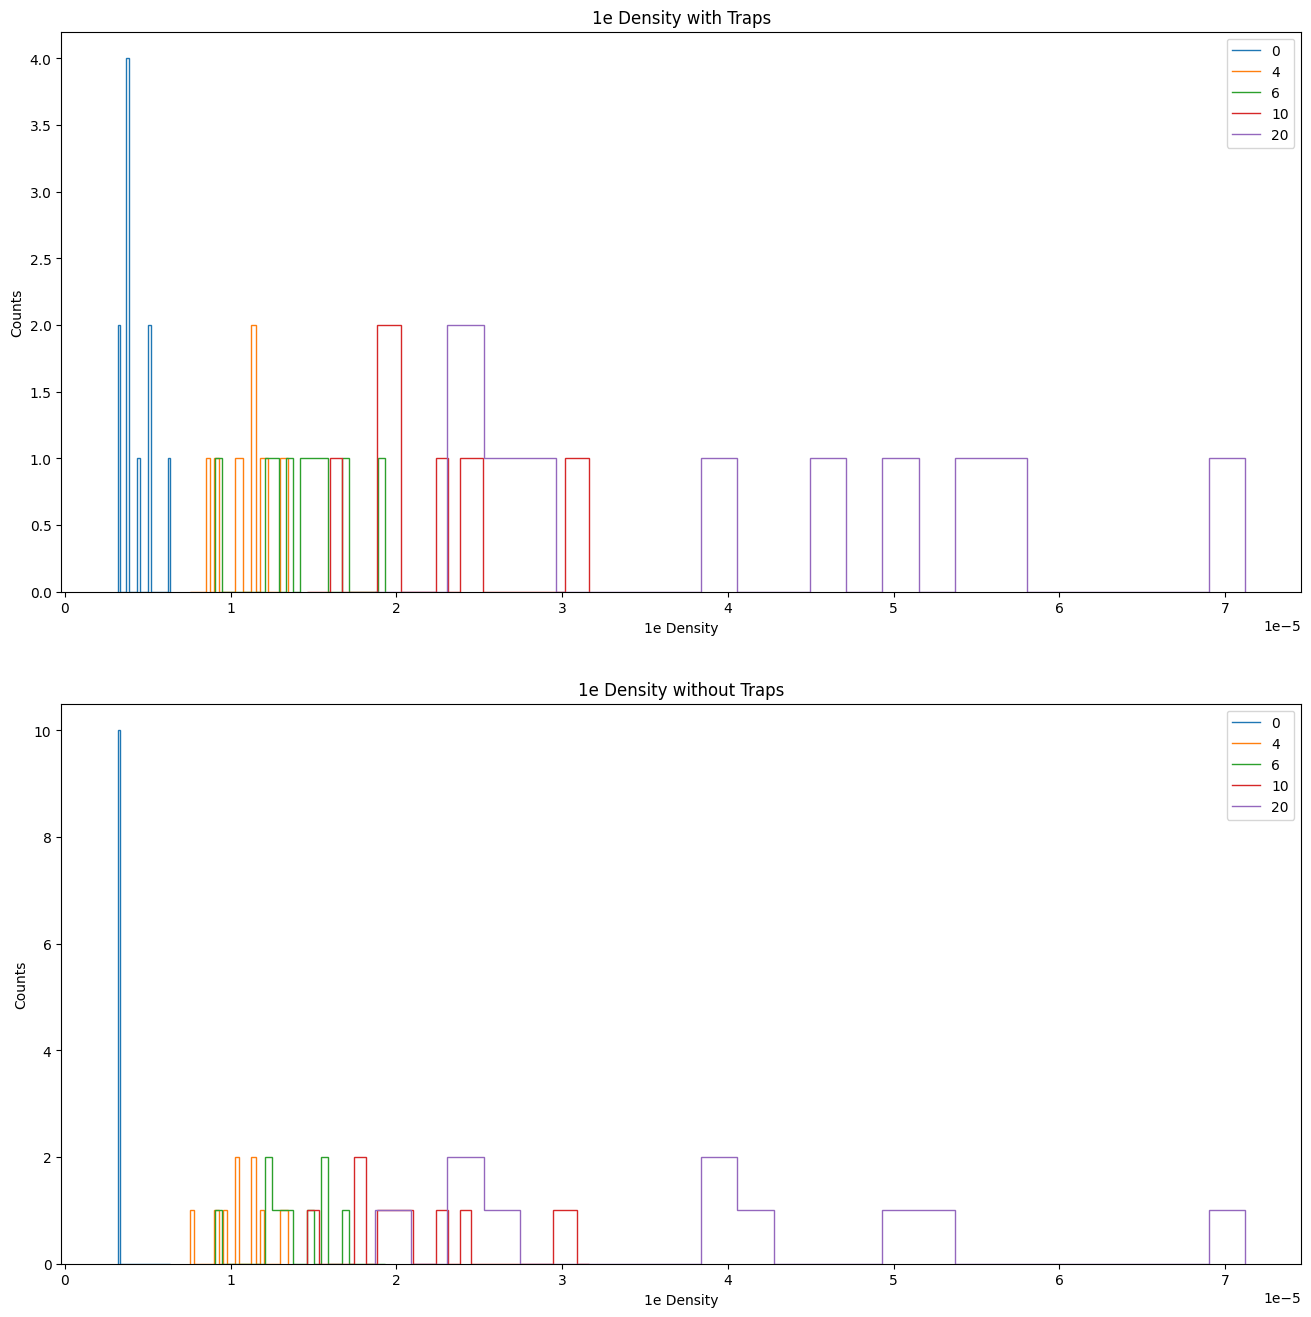

In [ ]:
exposures = np.array(CCDTest.exposures)

unique_exposures = np.unique(np.sort(exposures))
fig,ax = plt.subplots(2,figsize=(16,16))

averages = []
averages_notraps = []

for exp in unique_exposures:
    indices = exposures == exp
    single_es_trap  = np.array(CCDTest.single_e_counts_masked)[indices]

    single_es_notraps  = np.array(CCDTest.single_e_counts_masked_no_traps)[indices]

    unmasked_pix_trap = np.array(CCDTest.unmasked_pixels)[indices]
    unmasked_pix_notraps = np.array(CCDTest.unmasked_pixels_no_traps)[indices]

    single_e_density = single_es_trap / unmasked_pix_trap
    single_d_density_notraps = single_es_notraps / unmasked_pix_notraps

    averages_notraps.append(np.mean(single_d_density_notraps))
    averages.append(np.mean(single_e_density))

    bins = np.linspace(np.min(single_d_density_notraps),np.max(single_e_density),25)

    hist,bins = np.histogram(single_e_density,bins)
    ax[0].stairs(hist,bins,label=f'{int(exp /3600)}')

    hist,bins = np.histogram(single_d_density_notraps,bins)
    ax[1].stairs(hist,bins,label=f'{int(exp /3600)}')

ax[0].set_title("1e Density with Traps")
ax[1].set_title("1e Density without Traps")

ax[0].set_xlabel("1e Density")
ax[1].set_xlabel("1e Density")

ax[0].set_ylabel("Counts")
ax[1].set_ylabel("Counts")
ax[0].legend()
ax[1].legend()
plt.show()
plt.close()



    




With Traps
exposure independent: 3.6480605557568197e-06
exposure dependent: 4.615830988231501e-05
Without Traps
exposure independent: 3.3596668647437554e-06
exposure dependent: 4.294551484455089e-05
True Parameters
exposure independent: 3.10625e-06
exposure dependent: 4.36e-05


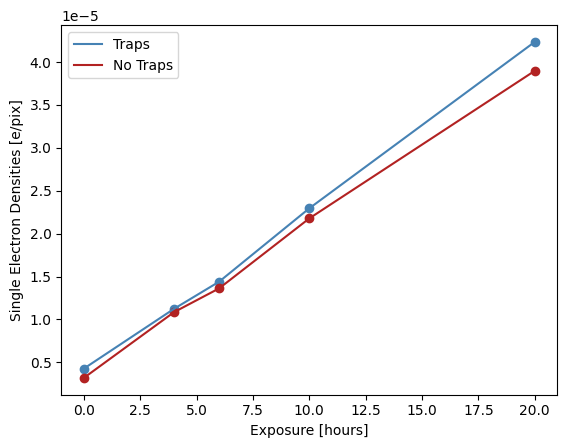

In [ ]:
from sklearn.linear_model import LinearRegression

days = unique_exposures / (24* 3600)
days = days.reshape((-1, 1))

model = LinearRegression().fit(days, averages)

exp_indep = model.intercept_
exp_dep = model.coef_[0]


model_notraps = LinearRegression().fit(days, averages_notraps)

exp_indep_notraps = model_notraps.intercept_
exp_dep_notraps = model_notraps.coef_[0]


plt.plot(unique_exposures/3600,averages,label='Traps',color='steelblue')
plt.scatter(unique_exposures/3600,averages,color='steelblue')
plt.plot(unique_exposures/3600,averages_notraps,label='No Traps',color='firebrick')
plt.scatter(unique_exposures/3600,averages_notraps,color='firebrick')
plt.legend()
plt.ylabel("Single Electron Densities [e/pix]")
plt.xlabel("Exposure [hours]")
print("With Traps")
print(f'exposure independent: {exp_indep}')
print(f'exposure dependent: {exp_dep}')


print("Without Traps")
print(f'exposure independent: {exp_indep_notraps}')
print(f'exposure dependent: {exp_dep_notraps}')

print("True Parameters")
print(f'exposure independent: {3.10625e-06}')
print(f'exposure dependent: {4.36e-05}')




In [255]:
counts_1e_no_halo_no_traps = np.array(counts_1e_no_halo_no_traps)
counts_1e_no_halo_traps = np.array(counts_1e_no_halo_traps)

counts_1e_masked_no_traps = np.array(counts_1e_masked_no_traps)
counts_1e_masked_traps = np.array(counts_1e_masked_traps)
unmasked_pixels_traps = np.array(unmasked_pixels_traps)
unmasked_pixels_no_traps = np.array(unmasked_pixels_no_traps)


counts_1e_no_halo_no_traps_err = np.sqrt(counts_1e_no_halo_no_traps)
counts_1e_no_halo_traps_err = np.sqrt(counts_1e_no_halo_traps)
counts_1e_masked_no_traps_err = np.sqrt(counts_1e_masked_no_traps)
counts_1e_masked_traps_err = np.sqrt(counts_1e_masked_traps)


rate_per_unmasked_pix_notraps = counts_1e_masked_no_traps / unmasked_pixels_no_traps
rate_per_unmasked_pix_traps = counts_1e_masked_traps / unmasked_pixels_traps

rate_per_unmasked_pix_notraps_err = counts_1e_masked_no_traps_err / unmasked_pixels_no_traps
rate_per_unmasked_pix_traps_err  = counts_1e_masked_traps_err / unmasked_pixels_traps



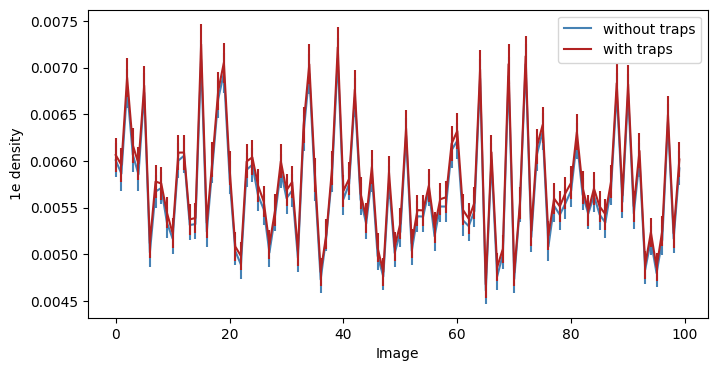

In [265]:
plt.figure(figsize=(8,4))
x = np.arange(len(rate_per_unmasked_pix_notraps))
plt.plot(x,rate_per_unmasked_pix_notraps,label='without traps',color='steelblue')
plt.errorbar(x,rate_per_unmasked_pix_notraps,yerr=rate_per_unmasked_pix_notraps_err,ls='',color='steelblue')

plt.plot(x,rate_per_unmasked_pix_traps,label='with traps',color='firebrick')
plt.errorbar(x,rate_per_unmasked_pix_traps,yerr=rate_per_unmasked_pix_traps_err,ls='',color='firebrick')

plt.xlabel("Image")
plt.ylabel("1e density")
plt.legend()
plt.show()
plt.close()

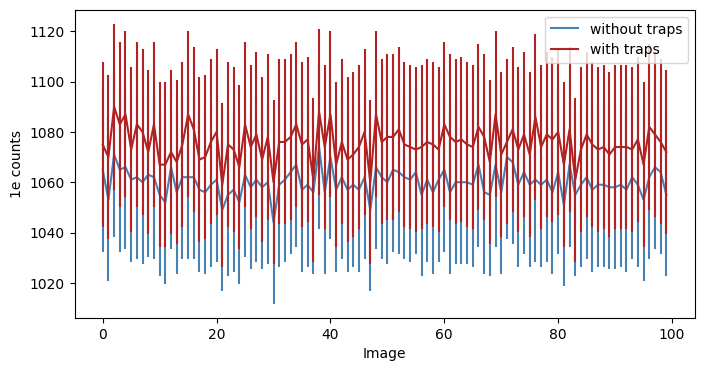

In [266]:
plt.figure(figsize=(8,4))



x = np.arange(len(counts_1e_no_halo_no_traps))
plt.plot(x,counts_1e_no_halo_no_traps,label='without traps',color='steelblue')
plt.errorbar(x,counts_1e_no_halo_no_traps,yerr=counts_1e_no_halo_no_traps_err,ls='',color='steelblue')

plt.plot(x,counts_1e_no_halo_traps,label='with traps',color='firebrick')
plt.errorbar(x,counts_1e_no_halo_traps,yerr=counts_1e_no_halo_traps_err,ls='',color='firebrick')

plt.xlabel("Image")
plt.ylabel("1e counts")
plt.legend()
plt.show()
plt.close()

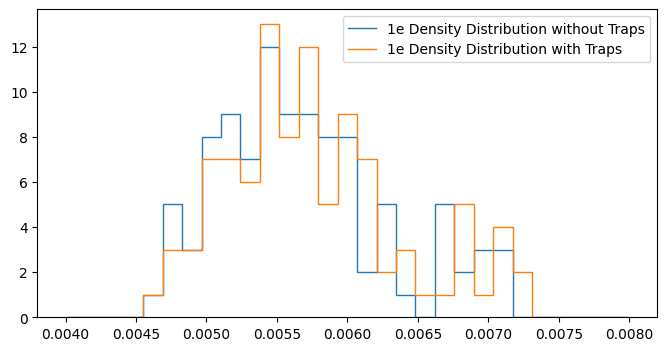

In [269]:
plt.figure(figsize=(8,4))

bins = np.linspace(0.004,0.008,30)
hist_notraps,bins = np.histogram(rate_per_unmasked_pix_notraps,bins=bins)
hist_traps,bins = np.histogram(rate_per_unmasked_pix_traps,bins=bins)

plt.stairs(hist_notraps,bins,label='1e Density Distribution without Traps')

plt.stairs(hist_traps,bins,label='1e Density Distribution with Traps')
plt.legend()
plt.show()
plt.close()

np.float64(18.0)

In [258]:
counts_1e_no_halo_no_traps_err

array([32.63433774, 32.44996148, 32.72613634, 32.63433774, 32.64965543,
       32.57299495, 32.58834147, 32.55764119, 32.60368077, 32.58834147,
       32.48076354, 32.43454948, 32.64965543, 32.49615362, 32.58834147,
       32.58834147, 32.58834147, 32.51153641, 32.49615362, 32.54228019,
       32.57299495, 32.38826948, 32.48076354, 32.51153641, 32.43454948,
       32.60368077, 32.52691193, 32.57299495, 32.52691193, 32.55764119,
       32.31098884, 32.54228019, 32.57299495, 32.61901286, 32.66496594,
       32.51153641, 32.54228019, 32.49615362, 32.77193922, 32.49615362,
       32.71085447, 32.51153641, 32.58834147, 32.51153641, 32.54228019,
       32.51153641, 32.58834147, 32.38826948, 32.64965543, 32.58834147,
       32.55764119, 32.63433774, 32.61901286, 32.58834147, 32.57299495,
       32.61901286, 32.48076354, 32.57299495, 32.49615362, 32.57299495,
       32.63433774, 32.49615362, 32.55764119, 32.55764119, 32.55764119,
       32.54228019, 32.66496594, 32.49615362, 32.48076354, 32.66

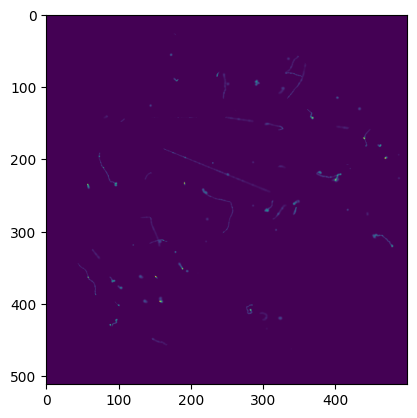

In [240]:
plt.imshow(CCDTest.no_trap_images[0][:,:500])

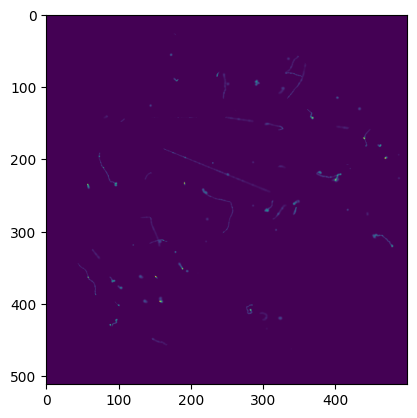

In [241]:
plt.imshow(CCDTest.reconstructed_images[0][:,:500])

In [ ]:
np.sum(CCDTest.reconstructed_images[0]/(512*3096)),np.sum(CCDTest.no_trap_images[0]/(512*3096)),np.sum(CCDTest.trapped_charge)

(np.float64(7.5783363361999365),
 np.float64(7.578347691577846),
 np.float64(14.0))

In [273]:
20 * 3600 /72000

1.0

In [275]:
exp = 72000
test = 21600

test / exp

0.3

In [225]:
og_image = CCDTest.no_trap_images[0]
trap_image = CCDTest.reconstructed_images[0]
og_image_halo = generate_halo_mask(og_image,threshold=100,radius=60)
trap_image_halo = generate_halo_mask(trap_image,threshold=100,radius=60)


masked_trap_image = np.copy(trap_image).astype(float)

masked_og_image = np.copy(og_image).astype(float)


In [230]:
np.sum(trap_image_halo),np.sum(~trap_image_halo)

(np.int64(1383403), np.int64(189461))

In [226]:
masked_trap_image[trap_image_halo] = np.nan

masked_og_image[og_image_halo] = np.nan


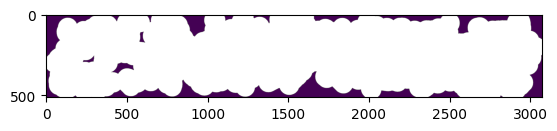

In [227]:
plt.imshow(masked_og_image)

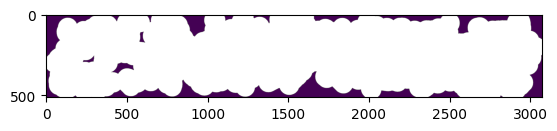

In [ ]:
plt.imshow(masked_trap_image)


In [229]:
counts_1e_trap  = get_cluster(masked_trap_image,min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)
counts_1e_og  = get_cluster(masked_og_image,min_pixs=1,max_pixs=1,min_total_value=1,max_total_value = 1,return_count=True)
counts_1e_og,counts_1e_trap

(6, 6)

In [141]:
shape = (512,3096)
rng = np.random.default_rng()
trap_mask = rng.random(shape) < trap_density
trap_mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(512, 3096))

In [110]:
ccd = CCDReadoutWithTraps(q0_fake,tau_values,tau_weights, readout_time_hours=7.0)
result = ccd.run_readout()

Starting Readout...
Time per pixel shift: 16.02 ms


In [111]:
result_reconstructed= result.reshape(512, 3072)
result_reconstructed = np.flipud(np.fliplr(result_reconstructed))

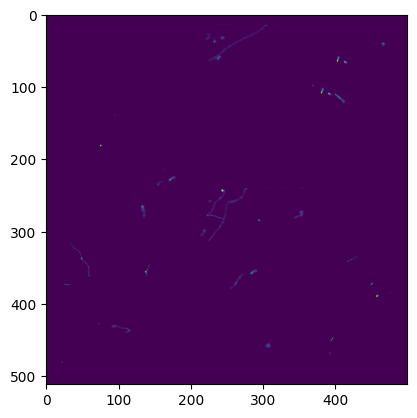

In [112]:
plt.imshow(q0_fake[:,:500])

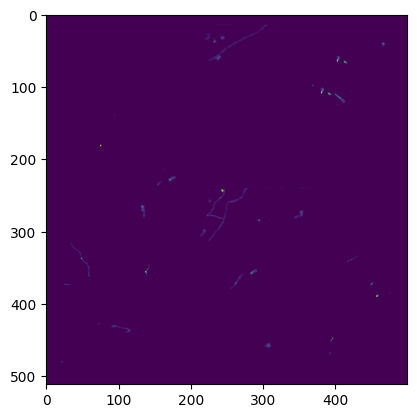

In [113]:
plt.imshow(result_reconstructed[:,:500])

In [116]:
halo_mask_original_fake = create_halo_mask(q0_fake)

count_truly_safe_events(q0_fake, halo_mask_original_fake)

np.int64(185)

In [ ]:
halo_mask_after_traps = create_halo_mask(result_reconstructed)

n_evts_after_masks = count_truly_safe_events(result_reconstructed, halo_mask_after_traps)



np.int64(7)

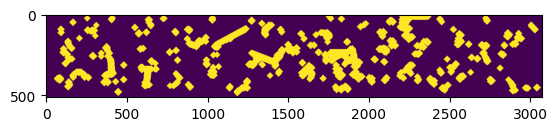

In [104]:
plt.imshow(halo_mask_after_traps)

In [124]:
np.sum(halo_mask_after_traps ), halo_mask_after_traps.shape[0] * halo_mask_after_traps.shape[1], np.sum(halo_mask_after_traps ) / (halo_mask_after_traps.shape[0] * halo_mask_after_traps.shape[1])

(np.int64(335893), 1572864, np.float64(0.21355501810709634))

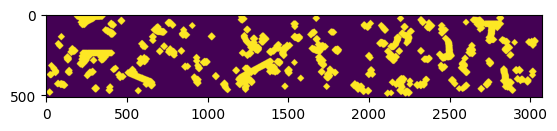

In [120]:
plt.imshow(halo_mask_original_fake)

In [125]:
np.sum(halo_mask_original_fake ), halo_mask_original_fake.shape[0] * halo_mask_original_fake.shape[1], np.sum(halo_mask_original_fake ) / (halo_mask_original_fake.shape[0] * halo_mask_after_traps.shape[1])

(np.int64(347386), 1572864, np.float64(0.22086207071940103))